In [1]:
# マイクロストラクチャ可視化 — 図の提案

## 3案

| # | 図の名称 | 内容 | 読み取れること |
|---|---------|------|--------------|
| 1 | **Spread・流動性タイムライン** | 上段: mid_price + trade_price（売買方向で色分け）、下段: bid_ask_spread_bps（rolling mean 付き） | スプレッド拡大＝流動性悪化の局面を時系列で特定できる。価格急変とスプレッド拡大の同時発生はストレスイベントを示唆 |
| 2 | **注文フロー累積 vs 価格変化** | 上段: mid_price、中段: signed_volume の累積和 + order_imbalance の rolling mean、下段: trade_size のバー | 累積 signed_volume の傾きが変わる点は注文フローの regime change。order_imbalance との乖離は hidden liquidity や iceberg 注文の存在を示唆 |
| 3 | **板の非対称性（Depth Imbalance）** | bid_depth / (bid_depth + ask_depth) の時系列 + signed_volume のヒストグラム | 板の偏りが一方向に傾く局面は、情報トレーダーの参入や大口注文の存在を反映する |

## 優先する2案とその理由

**案1（Spread・流動性タイムライン）** と **案2（注文フロー累積 vs 価格変化）** を選択。

- **案1を優先する理由**: bid-ask spread はマーケット・マイクロストラクチャにおける流動性の最も基本的な指標。スプレッドの時間変動を価格と重ねることで「いつ流動性が枯渇したか」が一目で分かり、他のすべての分析の起点になる。
- **案2を優先する理由**: signed_volume の累積と order_imbalance は注文フローの方向性バイアスを捉える。Kyle (1985) の λ（価格インパクト係数）の直感的な可視化であり、案1で検出した流動性悪化局面が「誰が原因か（情報トレーダー vs ノイズ）」を判別する手がかりになる。
- **案3を後回しにする理由**: depth imbalance は有用だが、bid/ask depth のスナップショット精度に依存しやすく、まず案1・2で全体像を掴んでから深掘りすべき。

SyntaxError: invalid character '・' (U+30FB) (8234087.py, line 7)

In [2]:
# ── 0. データ準備（df が存在しなければダミー生成） ──────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

if "df" not in dir() or not isinstance(df, pd.DataFrame):
    rng = np.random.default_rng(42)
    n = 2000
    ts = pd.date_range("2025-06-01 09:00", periods=n, freq="500ms")
    mid = 100 + np.cumsum(rng.normal(0, 0.02, n))
    spread_bps = np.clip(rng.exponential(3, n) + 1, 0.5, 30)
    # 流動性悪化イベントを挿入（index 800–900, 1400–1500）
    spread_bps[800:900] *= 3
    spread_bps[1400:1500] *= 2.5
    half_spread = mid * spread_bps / 1e4 / 2
    side = rng.choice([-1, 1], n)
    trade_price = mid + side * half_spread * rng.uniform(0.8, 1.2, n)
    trade_size = rng.exponential(50, n).astype(int) + 1
    signed_vol = side * trade_size
    bid_depth = rng.exponential(500, n) + 100
    ask_depth = rng.exponential(500, n) + 100
    order_imb = (bid_depth - ask_depth) / (bid_depth + ask_depth)

    df = pd.DataFrame({
        "timestamp": ts,
        "mid_price": mid,
        "trade_price": trade_price,
        "trade_size": trade_size,
        "bid_ask_spread_bps": spread_bps,
        "bid_depth": bid_depth,
        "ask_depth": ask_depth,
        "signed_volume": signed_vol,
        "order_imbalance": order_imb,
    })
    print(f"ダミーデータを生成しました: {df.shape}")
else:
    print(f"既存の df を使用: {df.shape}")

df.head(3)

ダミーデータを生成しました: (2000, 9)


,timestamp,mid_price,trade_price,trade_size,bid_ask_spread_bps,bid_depth,ask_depth,signed_volume,order_imbalance
0,2025-06-01 09:00:00.000,100.006094,100.010585,71,1.093114,1968.894807,241.733667,71,0.781299
1,2025-06-01 09:00:00.500,99.985295,99.975605,86,1.933518,170.088675,767.621932,-86,-0.637226
2,2025-06-01 09:00:01.000,100.000304,100.014553,39,2.716552,693.027395,321.927866,39,0.365631


C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_32428\1618568412.py:44: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_32428\1618568412.py:44: UserWarning: Glyph 12539 (\N{KATAKANA MIDDLE DOT}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_32428\1618568412.py:44: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_32428\1618568412.py:44: UserWarning: Glyph 21205 (\N{CJK UNIFIED IDEOGRAPH-52D5}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_32428\1618568412.py:44: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_32428\1618568412.py:44: UserWarning: Gly

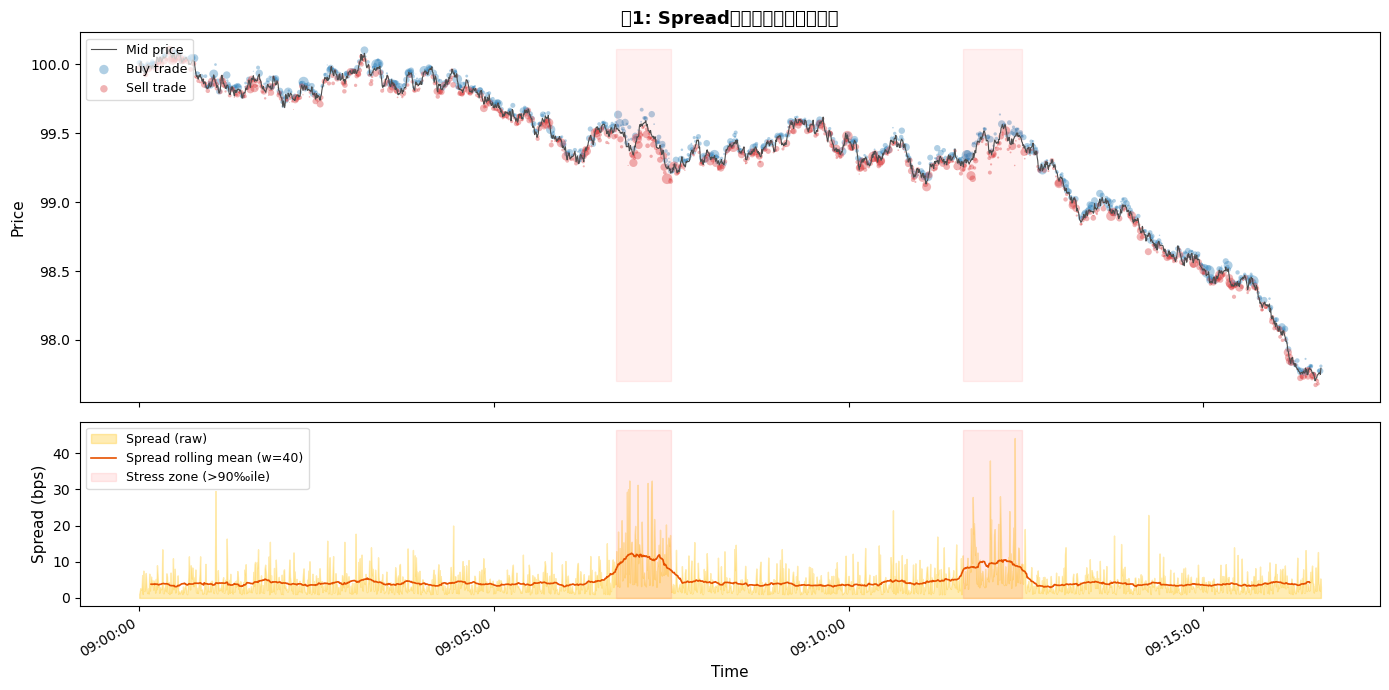

In [3]:
# ── 図1: Spread・流動性タイムライン ──────────────────────────────────
t = df["timestamp"]
ROLL = 40  # rolling window

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# ── 上段: mid_price + trade markers ──
ax1.plot(t, df["mid_price"], color="0.3", linewidth=0.8, label="Mid price")
buy = df["signed_volume"] > 0
sell = ~buy
ax1.scatter(t[buy], df.loc[buy, "trade_price"],
            s=df.loc[buy, "trade_size"] / df["trade_size"].quantile(0.95) * 30,
            c="#1f77b4", alpha=0.35, edgecolors="none", label="Buy trade")
ax1.scatter(t[sell], df.loc[sell, "trade_price"],
            s=df.loc[sell, "trade_size"] / df["trade_size"].quantile(0.95) * 30,
            c="#d62728", alpha=0.35, edgecolors="none", label="Sell trade")
ax1.set_ylabel("Price", fontsize=11)
ax1.set_title("図1: Spread・流動性タイムライン", fontsize=13, fontweight="bold")
ax1.legend(loc="upper left", fontsize=9, framealpha=0.7)

# ── 下段: bid-ask spread (bps) ──
ax2.fill_between(t, df["bid_ask_spread_bps"], color="#ffc107", alpha=0.3,
                  label="Spread (raw)")
roll_spread = df["bid_ask_spread_bps"].rolling(ROLL, center=True).mean()
ax2.plot(t, roll_spread, color="#e65100", linewidth=1.2,
         label=f"Spread rolling mean (w={ROLL})")

# スプレッド急拡大区間をハイライト
spread_thresh = roll_spread.quantile(0.90)
stress = roll_spread > spread_thresh
ax2.fill_between(t, 0, df["bid_ask_spread_bps"].max() * 1.05,
                  where=stress, color="red", alpha=0.08, label="Stress zone (>90‰ile)")
ax2.set_ylabel("Spread (bps)", fontsize=11)
ax2.set_xlabel("Time", fontsize=11)
ax2.legend(loc="upper left", fontsize=9, framealpha=0.7)

# 上段にもストレスゾーンを転写
ax1.fill_between(t, df["mid_price"].min(), df["mid_price"].max(),
                  where=stress, color="red", alpha=0.06)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
fig.autofmt_xdate(rotation=30)
fig.tight_layout()
plt.show()

C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_32428\1010295208.py:63: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_32428\1010295208.py:63: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_32428\1010295208.py:63: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_32428\1010295208.py:63: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_32428\1010295208.py:63: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_32428\1010295208.py:63: UserWarning: Glyph 12540 

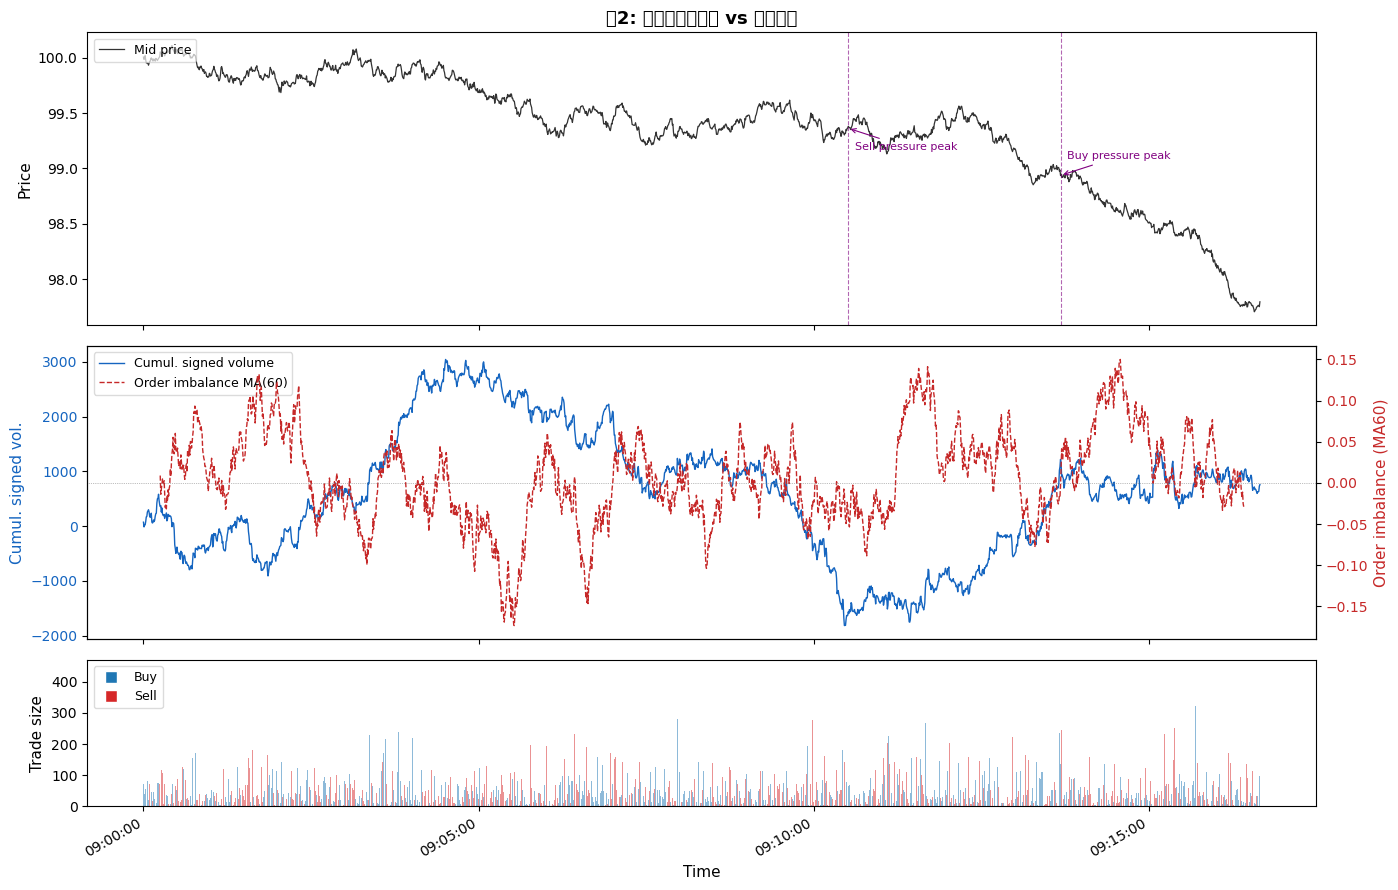

In [4]:
# ── 図2: 注文フロー累積 vs 価格変化 ──────────────────────────────────
OI_ROLL = 60  # order imbalance rolling window

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True,
                                     gridspec_kw={"height_ratios": [2, 2, 1]})

# ── 上段: mid_price ──
ax1.plot(t, df["mid_price"], color="0.2", linewidth=0.9, label="Mid price")
ax1.set_ylabel("Price", fontsize=11)
ax1.set_title("図2: 注文フロー累積 vs 価格変化", fontsize=13, fontweight="bold")
ax1.legend(loc="upper left", fontsize=9, framealpha=0.7)

# ── 中段: cumulative signed volume + order imbalance rolling ──
cum_sv = df["signed_volume"].cumsum()
ax2.plot(t, cum_sv, color="#1565c0", linewidth=1.0, label="Cumul. signed volume")
ax2.set_ylabel("Cumul. signed vol.", fontsize=11, color="#1565c0")
ax2.tick_params(axis="y", labelcolor="#1565c0")

ax2b = ax2.twinx()
oi_roll = df["order_imbalance"].rolling(OI_ROLL, center=True).mean()
ax2b.plot(t, oi_roll, color="#c62828", linewidth=1.0, linestyle="--",
          label=f"Order imbalance MA({OI_ROLL})")
ax2b.set_ylabel(f"Order imbalance (MA{OI_ROLL})", fontsize=11, color="#c62828")
ax2b.tick_params(axis="y", labelcolor="#c62828")
ax2b.axhline(0, color="grey", linewidth=0.5, linestyle=":")

# 凡例を手動統合
handles = [
    Line2D([0], [0], color="#1565c0", lw=1.0, label="Cumul. signed volume"),
    Line2D([0], [0], color="#c62828", lw=1.0, ls="--",
           label=f"Order imbalance MA({OI_ROLL})"),
]
ax2.legend(handles=handles, loc="upper left", fontsize=9, framealpha=0.7)

# ── 下段: trade_size バー（色は方向別） ──
colors = np.where(df["signed_volume"] > 0, "#1f77b4", "#d62728")
ax3.bar(t, df["trade_size"], width=pd.Timedelta("400ms"), color=colors, alpha=0.5)
ax3.set_ylabel("Trade size", fontsize=11)
ax3.set_xlabel("Time", fontsize=11)
legend_elements = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#1f77b4",
           markersize=8, label="Buy"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#d62728",
           markersize=8, label="Sell"),
]
ax3.legend(handles=legend_elements, loc="upper left", fontsize=9, framealpha=0.7)

# 注釈: cumulative signed volume の傾き転換点をマーク
sv_diff = cum_sv.diff(periods=50)
peak_idx = sv_diff.idxmax()
trough_idx = sv_diff.idxmin()
for idx, label, va in [(peak_idx, "Buy pressure peak", "bottom"),
                        (trough_idx, "Sell pressure peak", "top")]:
    ax1.axvline(t.iloc[idx], color="purple", linewidth=0.8, linestyle="--", alpha=0.6)
    ax1.annotate(label, xy=(t.iloc[idx], df["mid_price"].iloc[idx]),
                 fontsize=8, color="purple", ha="left", va=va,
                 xytext=(5, 10 if va == "bottom" else -10),
                 textcoords="offset points",
                 arrowprops=dict(arrowstyle="->", color="purple", lw=0.8))

ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
fig.autofmt_xdate(rotation=30)
fig.tight_layout()
plt.show()

# 図の読み方 — マイクロストラクチャの視点

## 図1: Spread・流動性タイムライン

| 着目ポイント | 読み方 |
|------------|--------|
| **赤い Stress zone** | rolling spread が 90 パーセンタイルを超えた区間。マーケットメイカーがリスクを認識してスプレッドを広げた＝**流動性供給が後退した局面**。 |
| **scatter の密度と色** | Buy (青) / Sell (赤) の塊が偏っている時間帯は、一方向への注文集中 (**order flow toxicity** の上昇) を示す。 |
| **spread の急拡大 → 急縮小** | V 字型の回復が速ければ一過性のイベント。じわじわ戻る場合は構造的な流動性シフトの可能性。 |

## 図2: 注文フロー累積 vs 価格変化

| 着目ポイント | 読み方 |
|------------|--------|
| **Cumul. signed volume の傾き** | 右肩上がり＝買い圧力優位、右肩下がり＝売り圧力優位。**傾きが変わる折れ曲がりポイント**が regime change。 |
| **Order imbalance MA とのずれ** | cumul. signed volume は増えているのに order_imbalance が中立付近 → 大口が板を食わずに **hidden/iceberg 注文**で吸収している可能性。 |
| **紫の注釈線 (pressure peak)** | signed volume の 50 期間差分が最大 / 最小の地点。ここで価格がどれだけ動いたかが **λ（Kyle's lambda = 価格インパクト係数）** の直感的な推定値になる。 |
| **下段 trade size バー** | 大きな棒が連続する区間はアグレッシブな執行。色の偏りと合わせて見ると、情報トレーダー vs ノイズトレーダーの判別材料になる。 |

> **次のステップ**: 案 3（Depth Imbalance）を追加し、板の非対称性が注文フロー偏りの *先行指標* になっているかを検証すると、より完全な市場構造分析になる。

---

# 短期リターン予測モデル — 問題設定と落とし穴

## 列の再確認

| 列 | 性質 | 注意 |
|----|------|------|
| `timestamp` | 時刻 | インデックスにする |
| `mid_price` | 観測時点のミッド | **説明変数に直接入れると非定常** |
| `future_mid_return_1min` | 1 分先リターン（目的変数候補） | **将来情報 → リーク厳禁** |
| `future_mid_return_5min` | 5 分先リターン（目的変数候補） | 同上 |
| `spread_bps` | ビッド・アスク・スプレッド | 流動性プロキシ |
| `depth_total` | 板の合計深さ | スケールが大きい → 正規化必要 |
| `signed_volume` | 符号付き出来高 | order flow の方向。累積するとトレンド成分が出る |
| `order_imbalance` | 注文インバランス | $[-1, 1]$ の有界変数 |
| `realized_vol_5min` | 5 分実現ボラティリティ | **計算窓が目的変数の予測ホライズンと重なる場合リーク** |
| `lagged_return_1min` | 1 分前リターン | 安全な特徴量（ただし自己相関弱い） |

## 落とし穴の整理

### 1. リーク (Look-ahead bias)
- `future_mid_return_*` は名前の通り将来値。**特徴量に絶対入れない。**
- `realized_vol_5min` の計算窓が $[t, t+5\text{min}]$ を含んでいれば目的変数 `future_mid_return_5min` とオーバーラップ → **リーク**。安全のため $[t-5\text{min}, t]$ で計算されていることを確認するか、自分で再計算する。

### 2. 内生性 (Endogeneity)
- `spread_bps` や `order_imbalance` は **mid_price と同時決定**。因果ではなく相関しか取れない。予測目的なら許容するが、「スプレッドが広がったから価格が下がった」とは言えない。

### 3. 多重共線性
- `signed_volume` と `order_imbalance` は概念が近く高相関になりやすい。VIF を確認し、片方を落とすか PCA で縮約する。

### 4. 非定常性
- `mid_price` は非定常（単位根）。**リターンに変換して使う。**
- `depth_total` もセッションごとにレベルがシフトしうる → 標準化 or 対数変換。

### 5. Regime change
- ボラティリティ・レジームが変わると、同じ特徴量でも係数の符号が反転しうる。
- 時系列 CV の窓を短くする or regime indicator を特徴量に追加。

### 6. 外れ値・スケーリング
- `signed_volume`, `depth_total` はファットテール。**Winsorize + RobustScaler** を検討。
- 線形モデルはスケーリング感度が高い。木系は不要だが、比較のため統一しておく方がよい。

---

## ベースラインモデル 2 案

### 案 A: Ridge 回帰（L2 正則化線形モデル）

$$\hat{y}_t = \mathbf{x}_t^\top \boldsymbol{\beta} + \beta_0, \quad \min_{\boldsymbol{\beta}} \sum_{t} (y_t - \hat{y}_t)^2 + \alpha \|\boldsymbol{\beta}\|_2^2$$

| 長所 | 短所 |
|------|------|
| 係数の解釈が容易 | 非線形パターンを捉えられない |
| 多重共線性に対し安定 (L2) | regime change に適応できない |
| 学習が高速 | 外れ値に弱い（Huber loss 併用で緩和可） |

### 案 B: LightGBM（勾配ブースティング木）

| 長所 | 短所 |
|------|------|
| 非線形・交互作用を自動検出 | 過学習しやすい（時系列では特に） |
| スケーリング不要 | 係数の解釈が難しい |
| 外れ値に頑健 | 時間方向のリークに気付きにくい |

---

## 学習・検証の切り方

```
時間 ────────────────────────────────────────────►
│◄── Train (60%) ──►│◄── Gap ──►│◄── Val (20%) ──►│◄── Test (20%) ──►│
                      予測ホライズン分
                      のギャップを空ける
```

- **時系列順 split のみ**（shuffle 禁止）
- Train / Val 間に **予測ホライズン（5 分）以上のギャップ** を挿入し、ターゲットのオーバーラップを防ぐ
- Expanding window CV も推奨だが、まずは固定 split で動かす

In [5]:
# ── 0. データ準備 ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import RobustScaler
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

REQUIRED_COLS = [
    "timestamp", "mid_price", "future_mid_return_1min", "future_mid_return_5min",
    "spread_bps", "depth_total", "signed_volume", "order_imbalance",
    "realized_vol_5min", "lagged_return_1min",
]

def _make_dummy(n=4000):
    rng = np.random.default_rng(0)
    ts = pd.date_range("2025-06-01 09:00", periods=n, freq="1s")
    mid = 100.0 + np.cumsum(rng.normal(0, 0.005, n))
    ret_1 = np.roll(np.diff(mid, prepend=mid[0]) / mid, -60)
    ret_5 = np.roll(np.diff(mid, prepend=mid[0]) / mid, -300)
    spread = np.clip(rng.exponential(2.0, n) + 0.5, 0.3, 25)
    spread[2000:2400] *= 3
    depth = rng.exponential(800, n) + 200
    sv = rng.normal(0, 100, n)
    oi = np.tanh(sv / 200 + rng.normal(0, 0.3, n))
    rv5 = pd.Series(np.diff(mid, prepend=mid[0])).rolling(300).std().fillna(0.001).values
    lag_ret = np.roll(np.diff(mid, prepend=mid[0]) / mid, 60)
    return pd.DataFrame({
        "timestamp": ts, "mid_price": mid,
        "future_mid_return_1min": ret_1, "future_mid_return_5min": ret_5,
        "spread_bps": spread, "depth_total": depth,
        "signed_volume": sv, "order_imbalance": oi,
        "realized_vol_5min": rv5, "lagged_return_1min": lag_ret,
    })

need_dummy = ("df" not in dir()) or (not isinstance(df, pd.DataFrame))
if not need_dummy:
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        print(f"必要列が不足: {missing} -> ダミーデータで代替")
        need_dummy = True

if need_dummy:
    df = _make_dummy()
    print(f"ダミーデータを生成: {df.shape}")
else:
    print(f"既存の df を使用: {df.shape}")

df = df.sort_values("timestamp").reset_index(drop=True)
print(f"期間: {df['timestamp'].iloc[0]} -> {df['timestamp'].iloc[-1]}")
df.head(3)

必要列が不足: ['future_mid_return_1min', 'future_mid_return_5min', 'spread_bps', 'depth_total', 'realized_vol_5min', 'lagged_return_1min'] -> ダミーデータで代替
ダミーデータを生成: (4000, 10)
期間: 2025-06-01 09:00:00 -> 2025-06-01 10:06:39


,timestamp,mid_price,future_mid_return_1min,future_mid_return_5min,spread_bps,depth_total,signed_volume,order_imbalance,realized_vol_5min,lagged_return_1min
0,2025-06-01 09:00:00,100.000629,-0.000022,0.000060,3.576900,559.615180,-4.470799,0.002706,0.001,0.000014
1,2025-06-01 09:00:01,99.999968,-0.000058,0.000032,3.418016,3679.081858,28.230384,-0.052291,0.001,0.000014
2,2025-06-01 09:00:02,100.003170,0.000087,0.000028,1.002731,478.241782,79.225922,0.776194,0.001,-0.000077


=== 基本統計 ===
        spread_bps  depth_total  signed_volume  order_imbalance  realized_vol_5min  lagged_return_1min  future_mid_return_5min
count  4000.000000  4000.000000    4000.000000      4000.000000        4000.000000         4000.000000             4000.000000
mean      2.873942   997.926476       0.557746         0.005353           0.004688           -0.000001               -0.000001
std       2.931976   796.299212      99.178673         0.461873           0.001068            0.000050                0.000050
min       0.500280   200.134893    -402.315865        -0.986352           0.001000           -0.000195               -0.000195
25%       1.117553   436.569842     -65.968233        -0.367125           0.004806           -0.000035               -0.000035
50%       2.006099   750.741502       0.204937         0.012017           0.004984           -0.000002               -0.000002
75%       3.513744  1304.608196      68.378692         0.380027           0.005122            0.00

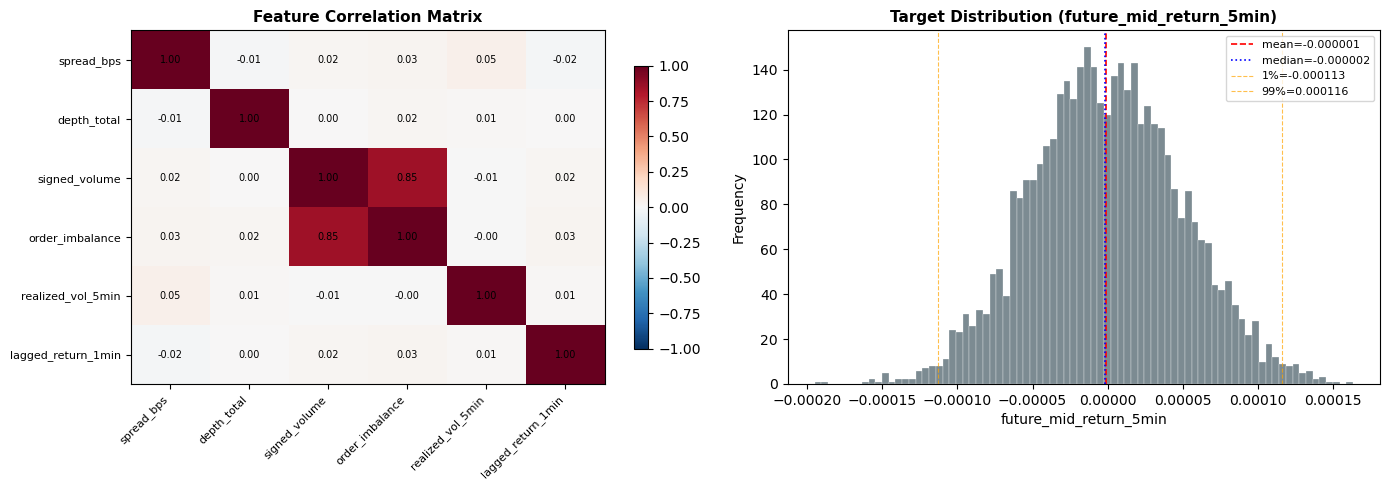

In [6]:
# ── 1. EDA & 診断 ────────────────────────────────────────────────────
FEATURES = ["spread_bps", "depth_total", "signed_volume",
            "order_imbalance", "realized_vol_5min", "lagged_return_1min"]
TARGET = "future_mid_return_5min"

print("=== 基本統計 ===")
print(df[FEATURES + [TARGET]].describe().round(6).to_string())

na_counts = df[FEATURES + [TARGET]].isna().sum()
print(f"\n=== 欠損数 ===\n{na_counts[na_counts > 0].to_string() if na_counts.any() else '欠損なし'}")

# 相関行列
corr = df[FEATURES].corr()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[0].set_xticks(range(len(FEATURES)))
axes[0].set_yticks(range(len(FEATURES)))
axes[0].set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=8)
axes[0].set_yticklabels(FEATURES, fontsize=8)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        axes[0].text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes[0], shrink=0.8)
axes[0].set_title("Feature Correlation Matrix", fontsize=11, fontweight="bold")

# VIF
from numpy.linalg import lstsq
X_feat = df[FEATURES].dropna().values
X_c = X_feat - X_feat.mean(axis=0)
vifs = []
for i in range(X_c.shape[1]):
    y_i = X_c[:, i]
    X_others = np.delete(X_c, i, axis=1)
    beta, *_ = lstsq(X_others, y_i, rcond=None)
    y_hat = X_others @ beta
    ss_res = np.sum((y_i - y_hat) ** 2)
    ss_tot = np.sum((y_i - y_i.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    vifs.append(1 / (1 - r2) if r2 < 1 else np.inf)
vif_df = pd.DataFrame({"feature": FEATURES, "VIF": vifs}).sort_values("VIF", ascending=False)
print(f"\n=== VIF (>5 要注意, >10 高共線性) ===\n{vif_df.to_string(index=False)}")

# 目的変数の分布
y = df[TARGET].dropna()
axes[1].hist(y, bins=80, color="#455a64", alpha=0.7, edgecolor="white", linewidth=0.3)
axes[1].axvline(y.mean(), color="red", linewidth=1.2, linestyle="--", label=f"mean={y.mean():.6f}")
axes[1].axvline(y.median(), color="blue", linewidth=1.2, linestyle=":", label=f"median={y.median():.6f}")
q01, q99 = y.quantile(0.01), y.quantile(0.99)
axes[1].axvline(q01, color="orange", linewidth=0.8, linestyle="--", alpha=0.7, label=f"1%={q01:.6f}")
axes[1].axvline(q99, color="orange", linewidth=0.8, linestyle="--", alpha=0.7, label=f"99%={q99:.6f}")
axes[1].set_xlabel(TARGET, fontsize=10)
axes[1].set_ylabel("Frequency", fontsize=10)
axes[1].set_title(f"Target Distribution ({TARGET})", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

In [7]:
# ── 2. 前処理 → 時系列 Split → 学習 → 評価 ─────────────────────────

# 欠損・外れ値処理
df_model = df[["timestamp"] + FEATURES + [TARGET]].dropna().copy()
for col in FEATURES:
    lo, hi = df_model[col].quantile(0.01), df_model[col].quantile(0.99)
    df_model[col] = df_model[col].clip(lo, hi)
print(f"モデル用データ: {df_model.shape[0]} rows (欠損除去後)")

# 時系列 Train / Val / Test split (gap 付き)
N = len(df_model)
GAP = 300  # 予測ホライズン(5min) 分のギャップ
train_end = int(N * 0.6)
val_start = train_end + GAP
val_end = val_start + int(N * 0.2)
test_start = val_end + GAP

train = df_model.iloc[:train_end]
val = df_model.iloc[val_start:val_end]
test = df_model.iloc[test_start:]

for name, part in [("Train", train), ("Val", val), ("Test", test)]:
    print(f"{name:5s}: {len(part):>5d} rows | "
          f"{part['timestamp'].iloc[0]} -> {part['timestamp'].iloc[-1]}")

# スケーリング (RobustScaler: train fit → val/test transform)
scaler = RobustScaler()
X_train = scaler.fit_transform(train[FEATURES])
X_val = scaler.transform(val[FEATURES])
X_test = scaler.transform(test[FEATURES])
y_train = train[TARGET].values
y_val = val[TARGET].values
y_test = test[TARGET].values

# === 案 A: Ridge 回帰 ===
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_val_ridge = ridge.predict(X_val)
pred_test_ridge = ridge.predict(X_test)

# === 案 B: LightGBM ===
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("lightgbm 未インストール -> Ridge のみで評価")

if HAS_LGB:
    gbm = lgb.LGBMRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_samples=30, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbose=-1,
    )
    gbm.fit(train[FEATURES].values, y_train,
            eval_set=[(val[FEATURES].values, y_val)],
            callbacks=[lgb.early_stopping(30, verbose=False)])
    pred_val_lgb = gbm.predict(val[FEATURES].values)
    pred_test_lgb = gbm.predict(test[FEATURES].values)

# 評価
def evaluate(y_true, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    ic, _ = spearmanr(y_true, y_pred)
    hit = np.mean(np.sign(y_true) == np.sign(y_pred))
    print(f"  [{label:20s}]  RMSE={rmse:.6f}  MAE={mae:.6f}  "
          f"R2={r2:+.4f}  IC(rank)={ic:+.4f}  Hit%={hit:.2%}")
    return dict(rmse=rmse, mae=mae, r2=r2, ic=ic, hit=hit)

print("\n=== Validation ===")
res_ridge_val = evaluate(y_val, pred_val_ridge, "Ridge (val)")
if HAS_LGB:
    res_lgb_val = evaluate(y_val, pred_val_lgb, "LightGBM (val)")

print("\n=== Test ===")
res_ridge_test = evaluate(y_test, pred_test_ridge, "Ridge (test)")
if HAS_LGB:
    res_lgb_test = evaluate(y_test, pred_test_lgb, "LightGBM (test)")

# Ridge 係数
coef_df = pd.DataFrame({
    "feature": FEATURES, "coef": ridge.coef_, "|coef|": np.abs(ridge.coef_),
}).sort_values("|coef|", ascending=False)
print(f"\n=== Ridge 係数 (alpha={ridge.alpha}) ===")
print(coef_df.to_string(index=False))

モデル用データ: 4000 rows (欠損除去後)
Train:  2400 rows | 2025-06-01 09:00:00 -> 2025-06-01 09:39:59
Val  :   800 rows | 2025-06-01 09:45:00 -> 2025-06-01 09:58:19
Test :   200 rows | 2025-06-01 10:03:20 -> 2025-06-01 10:06:39
lightgbm 未インストール -> Ridge のみで評価

=== Validation ===
  [Ridge (val)         ]  RMSE=0.000050  MAE=0.000040  R2=-0.0098  IC(rank)=-0.0315  Hit%=47.88%

=== Test ===
  [Ridge (test)        ]  RMSE=0.000052  MAE=0.000041  R2=+0.0001  IC(rank)=+0.1001  Hit%=58.00%

=== Ridge 係数 (alpha=1.0) ===
           feature          coef       |coef|
   order_imbalance  4.741241e-06 4.741241e-06
     signed_volume -1.525446e-06 1.525446e-06
lagged_return_1min  1.021473e-06 1.021473e-06
 realized_vol_5min -1.486710e-07 1.486710e-07
       depth_total  1.058346e-07 1.058346e-07
        spread_bps  1.049889e-07 1.049889e-07


*(セル 0〜2 のコードセルを上から順に実行してください)*

*(このセルは空です — 下の可視化セルに進んでください)*

*(このセルは空です)*

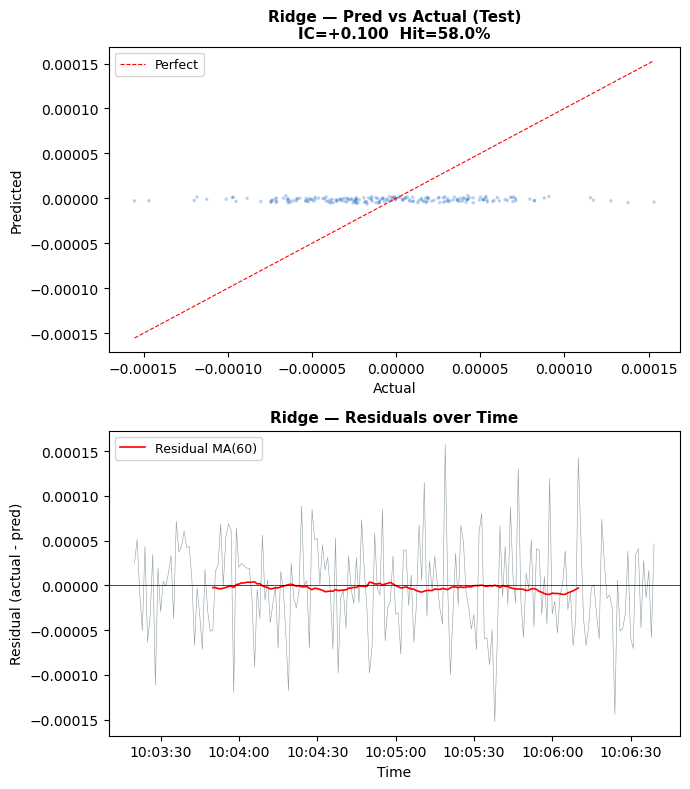

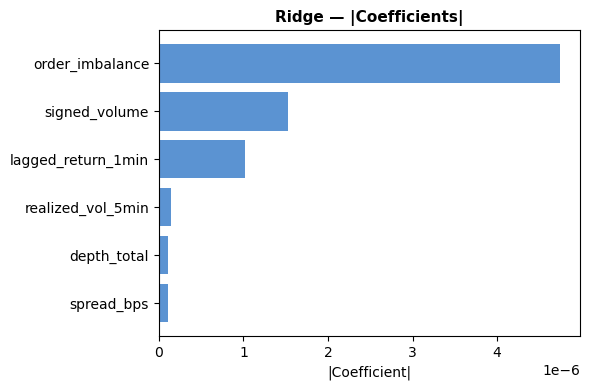

In [8]:
# ── 3. 可視化: 予測 vs 実績 + 残差 + 特徴量重要度 ────────────────────
n_models = 2 if HAS_LGB else 1
fig, axes = plt.subplots(2, n_models, figsize=(7 * n_models, 8))
if n_models == 1:
    axes = axes.reshape(-1, 1)

models_info = [("Ridge", pred_test_ridge, res_ridge_test)]
if HAS_LGB:
    models_info.append(("LightGBM", pred_test_lgb, res_lgb_test))

for col_idx, (name, pred, res) in enumerate(models_info):
    ax_sc = axes[0, col_idx]
    ax_re = axes[1, col_idx]

    # predicted vs actual
    ax_sc.scatter(y_test, pred, s=6, alpha=0.3, color="#1565c0", edgecolors="none")
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax_sc.plot(lims, lims, "r--", linewidth=0.8, label="Perfect")
    ax_sc.set_xlabel("Actual", fontsize=10)
    ax_sc.set_ylabel("Predicted", fontsize=10)
    ax_sc.set_title(f"{name} — Pred vs Actual (Test)\n"
                    f"IC={res['ic']:+.3f}  Hit={res['hit']:.1%}",
                    fontsize=11, fontweight="bold")
    ax_sc.legend(fontsize=9)

    # residuals
    residuals = y_test - pred
    t_test = test["timestamp"].values
    ax_re.plot(t_test, residuals, linewidth=0.4, color="#455a64", alpha=0.6)
    roll_res = pd.Series(residuals).rolling(60, center=True).mean()
    ax_re.plot(t_test, roll_res.values, color="red", linewidth=1.2,
               label="Residual MA(60)")
    ax_re.axhline(0, color="black", linewidth=0.5)
    ax_re.set_xlabel("Time", fontsize=10)
    ax_re.set_ylabel("Residual (actual - pred)", fontsize=10)
    ax_re.set_title(f"{name} — Residuals over Time", fontsize=11, fontweight="bold")
    ax_re.legend(fontsize=9)

fig.tight_layout()
plt.show()

# Feature importance
if HAS_LGB:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    sorted_idx = np.argsort(np.abs(ridge.coef_))
    ax1.barh([FEATURES[i] for i in sorted_idx], np.abs(ridge.coef_[sorted_idx]),
             color="#1565c0", alpha=0.7)
    ax1.set_xlabel("|Coefficient|", fontsize=10)
    ax1.set_title("Ridge — |Coefficients|", fontsize=11, fontweight="bold")
    imp = gbm.feature_importances_
    sorted_idx2 = np.argsort(imp)
    ax2.barh([FEATURES[i] for i in sorted_idx2], imp[sorted_idx2],
             color="#c62828", alpha=0.7)
    ax2.set_xlabel("Split importance", fontsize=10)
    ax2.set_title("LightGBM — Feature Importance", fontsize=11, fontweight="bold")
    fig.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    sorted_idx = np.argsort(np.abs(ridge.coef_))
    ax.barh([FEATURES[i] for i in sorted_idx], np.abs(ridge.coef_[sorted_idx]),
            color="#1565c0", alpha=0.7)
    ax.set_xlabel("|Coefficient|", fontsize=10)
    ax.set_title("Ridge — |Coefficients|", fontsize=11, fontweight="bold")
    fig.tight_layout()
    plt.show()

---

# まず最初に試すべき現実的な一案

**Ridge 回帰から始める。**

理由:
1. **解釈性**: 係数の符号・大きさで「どの特徴量が効いているか」が即座に分かる。マイクロストラクチャのドメイン知識と照合しやすい（例: `spread_bps` の係数が正 → スプレッド拡大時にリターンが正 → mean reversion 的）
2. **リーク検出が容易**: 異常に高い $R^2$ や IC が出たら、係数を見てどの変数が原因か特定できる。LightGBM だとこの切り分けが難しい
3. **オーバーフィットしにくい**: 4000 行程度の小サンプルでは、木系モデルは Val→Test で性能が落ちやすい。Ridge の L2 正則化は安定性で優る
4. **ベースライン確立**: Ridge の IC と Hit% が事前期待（IC ≈ 0.02–0.05、Hit ≈ 51–53%）を大きく超えたらリークを疑う、下回ったら特徴量を見直す、というサイクルの起点になる

## チェックリスト（次にやるべきこと）

- [ ] `realized_vol_5min` の計算窓が将来を含んでいないか確認
- [ ] Val → Test で IC/Hit が大きく劣化していないか（regime change の兆候）
- [ ] 残差プロットに時間的パターンがないか（→ あれば特徴量追加のヒント）
- [ ] VIF > 5 の特徴量ペアがあれば片方を除外して再実行
- [ ] Ridge が安定したら LightGBM に移行し、非線形ゲインを確認

---

# 戦略パフォーマンス可視化 — 図の提案

## 3案

| # | 図の名称 | パネル構成 | PM/投資家が読み取れること |
|---|---------|-----------|----------------------|
| 1 | **累積リターン + ドローダウン** | 上段: 累積リターン (Strategy vs Benchmark)、下段: Strategy のドローダウン水準 | 戦略の成長軌道とベンチマーク比較。ドローダウンの深さ・回復期間でテールリスクの実態が分かる |
| 2 | **ローリング指標ダッシュボード** | 上段: 60 日ローリング Sharpe、中段: 60 日ローリング超過リターン (α)、下段: Turnover + Gross Exposure の推移 | Sharpe が安定しているか、α がいつ消えたか、回転率・エクスポージャーの時間変動でコスト構造・リスク姿勢の変化を捉える |
| 3 | **リターン分布 + 月次ヒートマップ** | 左: Strategy vs Benchmark の日次リターンヒストグラム、右: 月次リターンのカレンダー・ヒートマップ | 分布の歪度・尖度でテールリスクを定量化。月次ヒートマップで季節性・特定月の弱さを特定 |

## 選択した2案とその理由

**案1（累積リターン + ドローダウン）** と **案2（ローリング指標ダッシュボード）** を選択。

- **案1を選ぶ理由**: PM/投資家が最初に見るべき図。累積リターンだけではリスクが隠れるが、ドローダウンを併記することで「最悪いくら沈んだか」「何日で回復したか」が一目で分かる。ベンチマーク線を重ねることで相対的価値も示せる。
- **案2を選ぶ理由**: 累積リターンは右肩上がりでも、ローリング Sharpe が劣化していればレジーム崩壊の兆候。Turnover/Exposure の推移はコスト源泉とリスクバジェットの消費状況を示し、「いつ戦略の性格が変わったか」を可視化できる。
- **案3を後回しにする理由**: 分布情報は有用だが、時間軸情報を失う。案1・2で時系列的な弱点を掴んでからドリルダウンする方が効率的。

In [9]:
# ── 0. データ準備 ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

PERF_COLS = ["date", "strategy_return", "benchmark_return", "turnover", "gross_exposure"]

def _make_perf_dummy(n=504):
    """約2年分の日次ダミーデータ"""
    rng = np.random.default_rng(7)
    dates = pd.bdate_range("2023-01-03", periods=n)
    # 戦略: 年率 Sharpe ≈ 1.2 → 日次 μ≈0.0005, σ≈0.008
    strat = rng.normal(0.0005, 0.008, n)
    # ドローダウン・イベント挿入
    strat[120:135] -= 0.015   # 2023年半ば
    strat[350:365] -= 0.012   # 2024年半ば
    bench = rng.normal(0.0003, 0.010, n)
    turn = np.clip(rng.exponential(0.08, n) + 0.02, 0.01, 0.6)
    turn[350:380] *= 2.0  # ドローダウン時に回転率上昇
    gexp = np.clip(rng.normal(1.0, 0.08, n), 0.7, 1.5)
    return pd.DataFrame({
        "date": dates,
        "strategy_return": strat,
        "benchmark_return": bench,
        "turnover": turn,
        "gross_exposure": gexp,
    })

need_dummy = ("df" not in dir()) or (not isinstance(df, pd.DataFrame))
if not need_dummy:
    missing = [c for c in PERF_COLS if c not in df.columns]
    if missing:
        print(f"必要列が不足: {missing} → ダミーデータで代替")
        need_dummy = True

if need_dummy:
    df = _make_perf_dummy()
    print(f"ダミーデータを生成: {df.shape}")
else:
    print(f"既存の df を使用: {df.shape}")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# 累積リターン
df["cum_strat"] = (1 + df["strategy_return"]).cumprod()
df["cum_bench"] = (1 + df["benchmark_return"]).cumprod()
# ドローダウン
df["peak"] = df["cum_strat"].cummax()
df["drawdown"] = df["cum_strat"] / df["peak"] - 1

# サマリ統計
ann = 252
mu_s = df["strategy_return"].mean() * ann
sig_s = df["strategy_return"].std() * np.sqrt(ann)
sr_s = mu_s / sig_s if sig_s > 0 else 0
max_dd = df["drawdown"].min()
mu_b = df["benchmark_return"].mean() * ann
print(f"期間: {df['date'].iloc[0].date()} → {df['date'].iloc[-1].date()} ({len(df)} days)")
print(f"Strategy  — Ann.Ret: {mu_s:+.2%}  Ann.Vol: {sig_s:.2%}  Sharpe: {sr_s:.2f}  MaxDD: {max_dd:.2%}")
print(f"Benchmark — Ann.Ret: {mu_b:+.2%}")
df[["date", "strategy_return", "benchmark_return", "turnover",
    "gross_exposure", "cum_strat", "cum_bench", "drawdown"]].tail(5)

必要列が不足: ['date', 'strategy_return', 'benchmark_return', 'turnover', 'gross_exposure'] → ダミーデータで代替
ダミーデータを生成: (504, 5)
期間: 2023-01-03 → 2024-12-06 (504 days)
Strategy  — Ann.Ret: -33.87%  Ann.Vol: 13.07%  Sharpe: -2.59  MaxDD: -50.83%
Benchmark — Ann.Ret: +6.59%


,date,strategy_return,benchmark_return,turnover,gross_exposure,cum_strat,cum_bench,drawdown
499,2024-12-02,-0.008123,0.020509,0.095846,1.075253,0.503716,1.087646,-0.497992
500,2024-12-03,-0.001783,0.004010,0.029680,1.105804,0.502818,1.092008,-0.498887
501,2024-12-04,-0.011550,0.018069,0.115966,0.908101,0.497010,1.111740,-0.504675
502,2024-12-05,-0.007318,0.009891,0.028516,0.891573,0.493373,1.122736,-0.508300
503,2024-12-06,0.011587,-0.006323,0.120229,1.028045,0.499089,1.115637,-0.502603


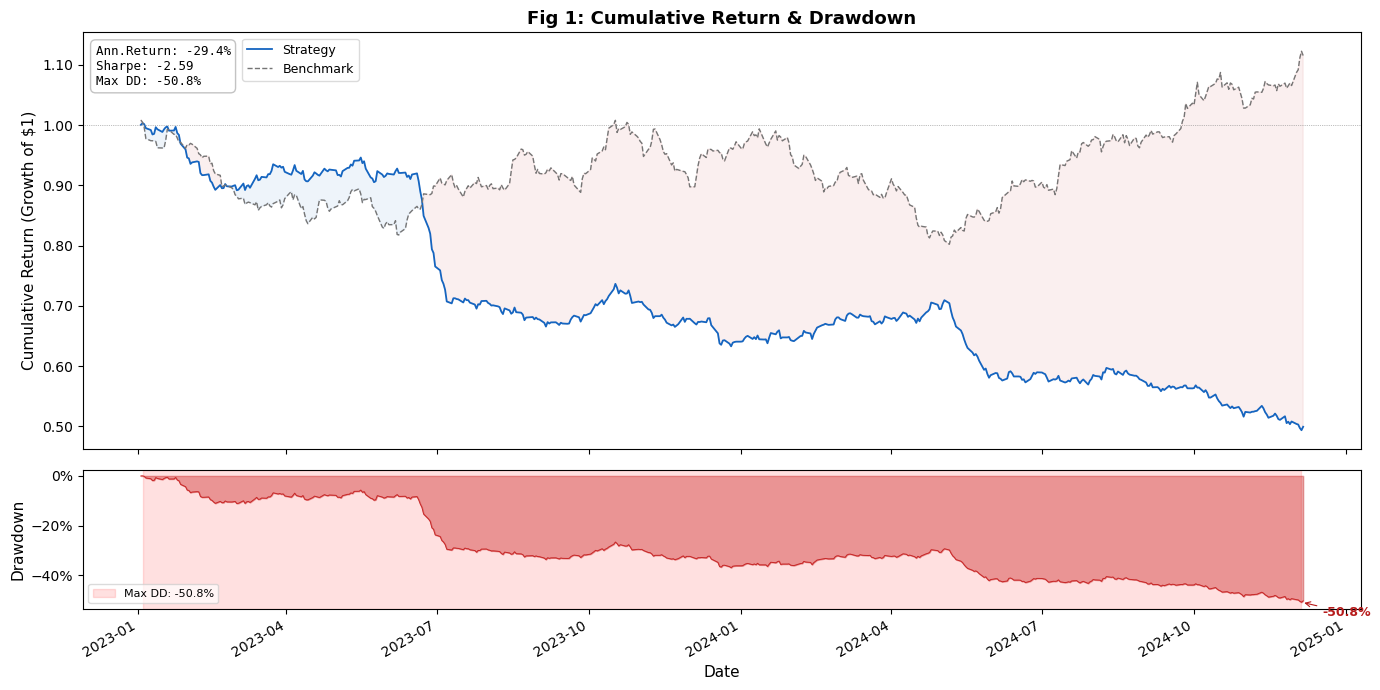

In [12]:
# ── 図1: 累積リターン + ドローダウン ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

# ── 上段: 累積リターン ──
ax1.plot(df["date"], df["cum_strat"], color="#1565c0", linewidth=1.3, label="Strategy")
ax1.plot(df["date"], df["cum_bench"], color="#757575", linewidth=1.0,
         linestyle="--", label="Benchmark")
ax1.fill_between(df["date"], df["cum_strat"], df["cum_bench"],
                  where=df["cum_strat"] >= df["cum_bench"],
                  color="#1565c0", alpha=0.07)
ax1.fill_between(df["date"], df["cum_strat"], df["cum_bench"],
                  where=df["cum_strat"] < df["cum_bench"],
                  color="#c62828", alpha=0.07)
ax1.axhline(1.0, color="grey", linewidth=0.5, linestyle=":")

# KPI 注釈（右上）
ann_ret = (df["cum_strat"].iloc[-1]) ** (ann / len(df)) - 1
kpi_text = (f"Ann.Return: {ann_ret:+.1%}\n"
            f"Sharpe: {sr_s:.2f}\n"
            f"Max DD: {max_dd:.1%}")
ax1.text(0.01, 0.97, kpi_text, transform=ax1.transAxes, fontsize=9,
         verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#bdbdbd", alpha=0.9))

ax1.set_ylabel("Cumulative Return (Growth of $1)", fontsize=11)
ax1.set_title("Fig 1: Cumulative Return & Drawdown", fontsize=13, fontweight="bold")
ax1.legend(loc="upper left", fontsize=9, framealpha=0.7, bbox_to_anchor=(0.12, 1.0))
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

# ── 下段: ドローダウン ──
ax2.fill_between(df["date"], df["drawdown"], 0, color="#c62828", alpha=0.4)
ax2.plot(df["date"], df["drawdown"], color="#c62828", linewidth=0.7)

# 最大ドローダウン区間をハイライト
dd_end_idx = df["drawdown"].idxmin()
dd_start_idx = df.loc[:dd_end_idx, "cum_strat"].idxmax()
ax2.axvspan(df["date"].iloc[dd_start_idx], df["date"].iloc[dd_end_idx],
            color="red", alpha=0.12, label=f"Max DD: {max_dd:.1%}")
ax2.annotate(f"{max_dd:.1%}", xy=(df["date"].iloc[dd_end_idx], max_dd),
             fontsize=9, color="#b71c1c", fontweight="bold",
             xytext=(15, -10), textcoords="offset points",
             arrowprops=dict(arrowstyle="->", color="#b71c1c", lw=0.8))

ax2.set_ylabel("Drawdown", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax2.legend(loc="lower left", fontsize=8, framealpha=0.7)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=30)
fig.tight_layout()
plt.show()

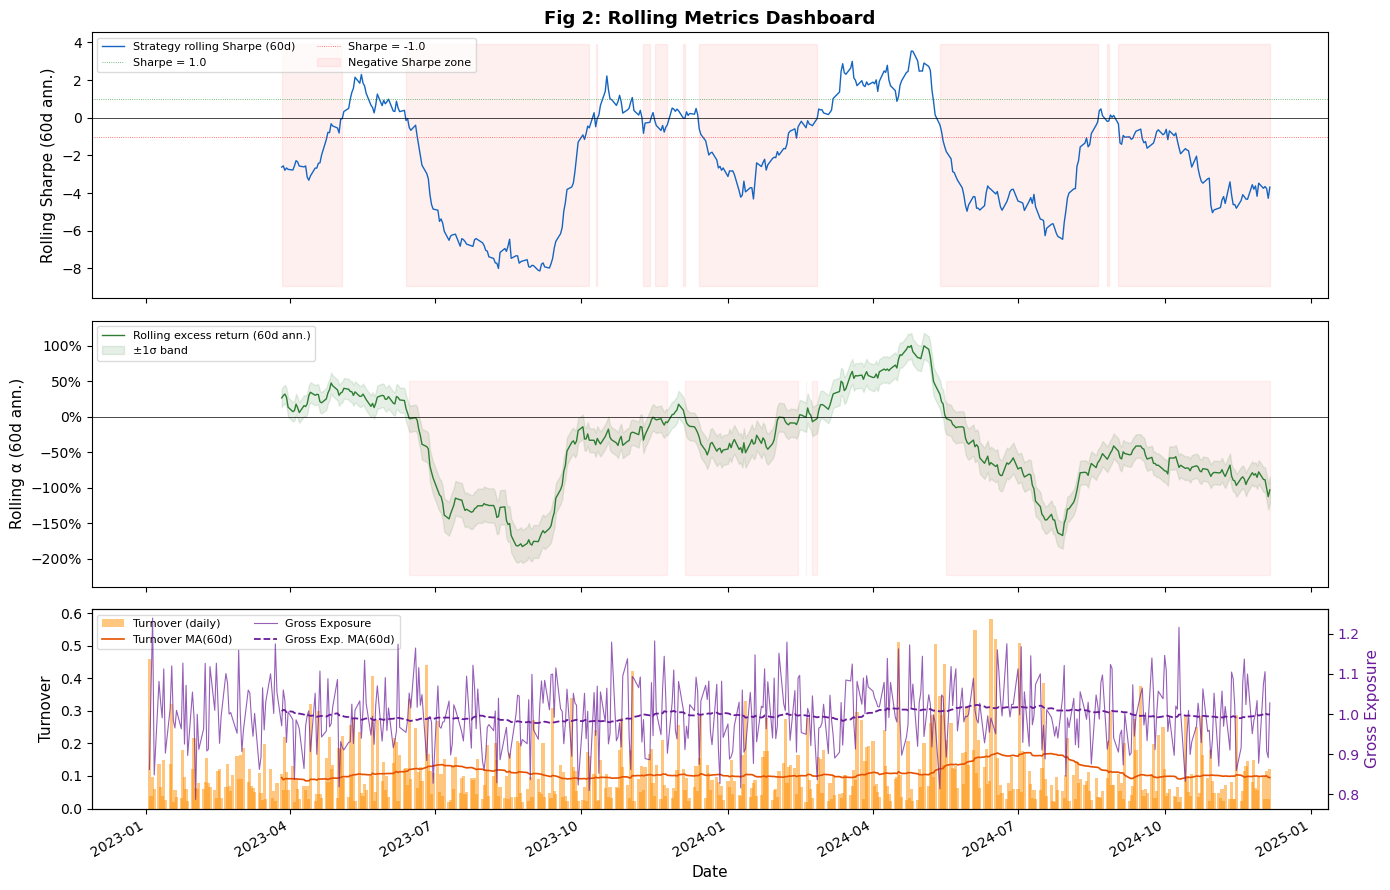

In [13]:
# ── 図2: ローリング指標ダッシュボード ──────────────────────────────────
ROLL_W = 60  # ローリング窓 (営業日)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True,
                                     gridspec_kw={"height_ratios": [2, 2, 1.5]})

# ── 上段: ローリング Sharpe ──
roll_mu = df["strategy_return"].rolling(ROLL_W).mean() * ann
roll_sig = df["strategy_return"].rolling(ROLL_W).std() * np.sqrt(ann)
roll_sharpe = roll_mu / roll_sig

ax1.plot(df["date"], roll_sharpe, color="#1565c0", linewidth=1.0, label=f"Strategy rolling Sharpe ({ROLL_W}d)")
ax1.axhline(0, color="black", linewidth=0.5)
ax1.axhline(1.0, color="green", linewidth=0.6, linestyle=":", alpha=0.7, label="Sharpe = 1.0")
ax1.axhline(-1.0, color="red", linewidth=0.6, linestyle=":", alpha=0.7, label="Sharpe = -1.0")

# Sharpe < 0 の区間をハイライト
neg_sharpe = roll_sharpe < 0
ax1.fill_between(df["date"], roll_sharpe.min() * 1.1, roll_sharpe.max() * 1.1,
                  where=neg_sharpe, color="red", alpha=0.06, label="Negative Sharpe zone")
ax1.set_ylabel(f"Rolling Sharpe ({ROLL_W}d ann.)", fontsize=11)
ax1.set_title("Fig 2: Rolling Metrics Dashboard", fontsize=13, fontweight="bold")
ax1.legend(loc="upper left", fontsize=8, framealpha=0.7, ncol=2)

# ── 中段: ローリング超過リターン (α) ──
excess = df["strategy_return"] - df["benchmark_return"]
roll_alpha = excess.rolling(ROLL_W).mean() * ann
roll_alpha_std = excess.rolling(ROLL_W).std() * np.sqrt(ann)
upper = roll_alpha + roll_alpha_std
lower = roll_alpha - roll_alpha_std

ax2.plot(df["date"], roll_alpha, color="#2e7d32", linewidth=1.0,
         label=f"Rolling excess return ({ROLL_W}d ann.)")
ax2.fill_between(df["date"], lower, upper, color="#2e7d32", alpha=0.12,
                  label="±1σ band")
ax2.axhline(0, color="black", linewidth=0.5)
neg_alpha = roll_alpha < 0
ax2.fill_between(df["date"], ax2.get_ylim()[0] if ax2.get_ylim()[0] < 0 else -0.5,
                  0.5, where=neg_alpha, color="red", alpha=0.05)
# 再描画のため ylim 調整後にハイライト
ax2.set_ylabel(f"Rolling α ({ROLL_W}d ann.)", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax2.legend(loc="upper left", fontsize=8, framealpha=0.7)

# ── 下段: Turnover + Gross Exposure ──
ax3.bar(df["date"], df["turnover"], width=2, color="#ff8f00", alpha=0.5, label="Turnover (daily)")
roll_turn = df["turnover"].rolling(ROLL_W).mean()
ax3.plot(df["date"], roll_turn, color="#e65100", linewidth=1.2,
         label=f"Turnover MA({ROLL_W}d)")
ax3.set_ylabel("Turnover", fontsize=11)
ax3.set_xlabel("Date", fontsize=11)

ax3b = ax3.twinx()
ax3b.plot(df["date"], df["gross_exposure"], color="#6a1b9a", linewidth=0.8,
          alpha=0.7, label="Gross Exposure")
roll_gexp = df["gross_exposure"].rolling(ROLL_W).mean()
ax3b.plot(df["date"], roll_gexp, color="#6a1b9a", linewidth=1.3,
          linestyle="--", label=f"Gross Exp. MA({ROLL_W}d)")
ax3b.set_ylabel("Gross Exposure", fontsize=11, color="#6a1b9a")
ax3b.tick_params(axis="y", labelcolor="#6a1b9a")

# 凡例統合
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
handles = [
    Patch(facecolor="#ff8f00", alpha=0.5, label="Turnover (daily)"),
    Line2D([0], [0], color="#e65100", lw=1.2, label=f"Turnover MA({ROLL_W}d)"),
    Line2D([0], [0], color="#6a1b9a", lw=0.8, alpha=0.7, label="Gross Exposure"),
    Line2D([0], [0], color="#6a1b9a", lw=1.3, ls="--", label=f"Gross Exp. MA({ROLL_W}d)"),
]
ax3.legend(handles=handles, loc="upper left", fontsize=8, framealpha=0.7, ncol=2)

ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=30)
fig.tight_layout()
plt.show()

---

# 各図の読み方 — 弱点・リスクの補足

## 図1: 累積リターン + ドローダウン

| 着目ポイント | 何が分かるか |
|------------|------------|
| **Strategy vs Benchmark の面積** | 青い塗り＝超過リターンが正、赤い塗り＝ベンチ負け。面積の厚みが α の蓄積量 |
| **ドローダウンの深さ** | Max DD の絶対値が戦略のテールリスク。投資家の心理的許容限度（通常 -10%〜-15%）と比較する |
| **ドローダウンの回復期間** | 赤い領域の横幅 = 回復に要した日数。長いほど資金拘束リスクが高い |
| **KPI ボックス** | Ann.Return / Sharpe / Max DD を一目で確認。Sharpe > 1 かつ Max DD < 15% が機関投資家の一般的な閾値 |

**この図が補足するリスク**: 累積リターンだけでは見えない「水面下の痛み」。PM はドローダウンの深さ×期間で戦略の生存可能性を判断する。

## 図2: ローリング指標ダッシュボード

| 着目ポイント | 何が分かるか |
|------------|------------|
| **Rolling Sharpe の赤ゾーン** | Sharpe < 0 の期間＝戦略が負けている時間帯。総期間に対する比率が高いと、累積リターンが正でもリスク調整後の質が悪い |
| **Rolling α の ±1σ バンド** | バンドが 0 を含む ≈ α が統計的に有意でない。バンドが全体的に正なら安定した超過リターン |
| **Turnover の急上昇** | ドローダウン時に Turnover が跳ね上がっていれば、損切り連鎖やモデル回転の兆候。**取引コスト増 → α 侵食**のリスク |
| **Gross Exposure の変動** | Exposure が急落＝リスクオフ（ポジション圧縮）。上昇＝レバレッジ拡大。中段の α が消えている時期と重なれば、リスク管理の失敗を示唆 |

**この図が補足するリスク**: 「戦略は一貫して機能しているか」という時間安定性の問い。累積リターンが右肩上がりでも、Rolling Sharpe が劣化トレンドなら regime change の前兆。Turnover/Exposure の同時急変はオペレーショナル・リスクのシグナル。